# Travelling Salesman Problem: Local Search vs Evolutionary Algorithm

**Module:** UFCEL1-15-M — AI for Search and Optimisation  
**Problem:** Find the shortest closed route visiting 50 cities exactly once and returning to the start.

This notebook compares a **single-solution local search** (Simulated Annealing, with a Hill Climbing baseline) against a **population-based evolutionary algorithm** (a Genetic Algorithm with permutation-safe operators). All algorithm logic lives in the `src/` package; this notebook imports it and runs the experiments.


## 0. Setup
We add the project root to the path so the `src` package can be imported regardless of where Jupyter is launched from.

In [1]:
import sys
from pathlib import Path

# Find the project root (the folder that contains 'src').
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt

from src.tsp import (load_cities, build_distance_matrix, tour_length,
                     plot_tour, plot_convergence, write_route)
from src.simulated_annealing import simulated_annealing
from src.hill_climbing import hill_climbing
from src.genetic_algorithm import genetic_algorithm
from src.tabu_search import tabu_search
from src.experiments import (run_repeated, statistical_comparison,
                             scalability_study)

DATA = root / 'data' / 'cities.csv'
print('Project root:', root)

Project root: /home/claude/tsp-optimisation


## 1. Load the problem and build the distance matrix
We read the city coordinates and pre-compute every pairwise Euclidean distance once. Every algorithm then evaluates a tour using the same objective function — the total length of the closed route — which keeps the comparison fair.

Loaded 50 cities


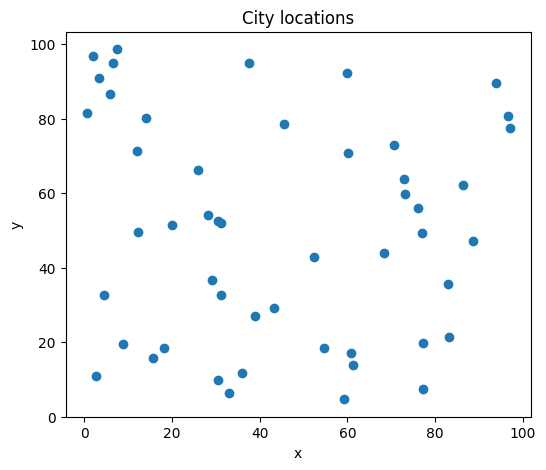

In [2]:
coords = load_cities(DATA)
dist = build_distance_matrix(coords)
print(f'Loaded {len(coords)} cities')

plt.figure(figsize=(6, 5))
plt.scatter(coords[:, 0], coords[:, 1])
plt.title('City locations')
plt.xlabel('x'); plt.ylabel('y'); plt.show()

## 2. Simulated Annealing (chosen single-member algorithm)
Simulated Annealing accepts a worse tour with probability `exp(-delta / T)`. A high starting temperature explores widely; the geometric cooling schedule `T = alpha * T` gradually shifts the search from exploration to exploitation. The neighbourhood move is a **2-opt segment reversal**, which is far more effective for TSP than the simple swap used in the lecture worked example because it removes crossed edges.

Best tour length (SA): 579.60


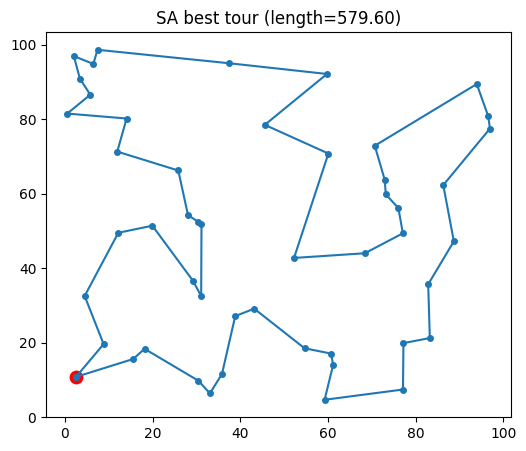

In [3]:
sa_tour, sa_len, sa_hist = simulated_annealing(dist, seed=0)
print(f'Best tour length (SA): {sa_len:.2f}')
ordered = coords[np.asarray(sa_tour + [sa_tour[0]])]
plt.figure(figsize=(6, 5))
plt.plot(ordered[:, 0], ordered[:, 1], '-o', ms=4)
plt.scatter(coords[sa_tour[0], 0], coords[sa_tour[0], 1], c='red', s=80)
plt.title(f'SA best tour (length={sa_len:.2f})'); plt.show()

## 3. Genetic Algorithm (evolutionary algorithm)

**Key point — why the basic lecture operators do not work here.** The introductory GA evolves a fixed vector `[x, y, z, w]` with single-point crossover and random-value mutation. A TSP tour is a *permutation*: single-point crossover would duplicate some cities and drop others, producing an invalid route. This GA therefore uses **Order Crossover (OX1)** and **inversion mutation**, both of which always return a valid permutation. Tournament selection drives the search (roulette wheel is also available in `src/genetic_algorithm.py` for comparison).

Best tour length (GA): 596.06


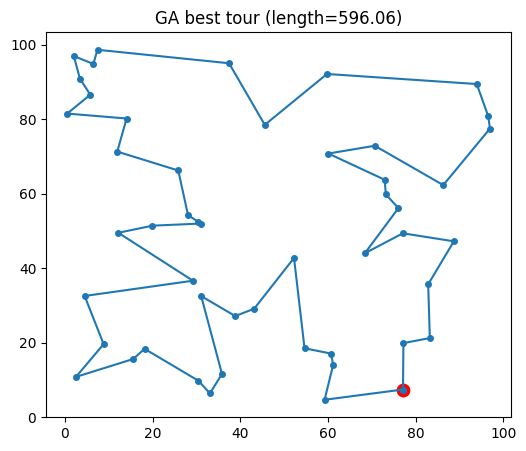

In [4]:
ga_tour, ga_len, ga_hist = genetic_algorithm(dist, seed=0)
print(f'Best tour length (GA): {ga_len:.2f}')
ordered = coords[np.asarray(ga_tour + [ga_tour[0]])]
plt.figure(figsize=(6, 5))
plt.plot(ordered[:, 0], ordered[:, 1], '-o', ms=4)
plt.scatter(coords[ga_tour[0], 0], coords[ga_tour[0], 1], c='red', s=80)
plt.title(f'GA best tour (length={ga_len:.2f})'); plt.show()

## 4. Hill Climbing baseline
A pure stochastic hill climber accepts only improving moves, so it has no way to escape a local optimum. It is included to show the weakness the lectures describe — it is the fastest method but tends to stall at a worse tour.

In [5]:
hc_tour, hc_len, hc_hist = hill_climbing(dist, seed=0)
print(f'Best tour length (Hill Climbing): {hc_len:.2f}')

Best tour length (Hill Climbing): 597.41


## 4b. Tabu Search (second single-member comparator)

Tabu Search maintains a short-term memory (the *tabu list*) of recently visited moves, preventing the search from immediately reversing a 2-opt swap it has just performed. At each iteration it selects the best admissible neighbour, even if it is worse than the current tour, and a move that would otherwise be forbidden is allowed if it improves on the best tour found so far (the *aspiration criterion*). Like Simulated Annealing it uses the 2-opt neighbourhood, so any difference in performance is attributable to the search strategy rather than to the move operator.

In [ ]:
ts_tour, ts_len, ts_hist = tabu_search(dist, seed=0)
print(f'Best tour length (Tabu Search): {ts_len:.2f}')
ordered = coords[np.asarray(ts_tour + [ts_tour[0]])]
plt.figure(figsize=(6, 5))
plt.plot(ordered[:, 0], ordered[:, 1], '-o', ms=4)
plt.scatter(coords[ts_tour[0], 0], coords[ts_tour[0], 1], c='red', s=80)
plt.title(f'Tabu Search best tour (length={ts_len:.2f})'); plt.show()

## 5. Convergence comparison
Best-tour-length-so-far against each algorithm's own iteration unit (temperature levels for SA, generations for GA, candidate moves for HC). SA and GA keep improving for far longer than the hill climber, which flat-lines once it is trapped.

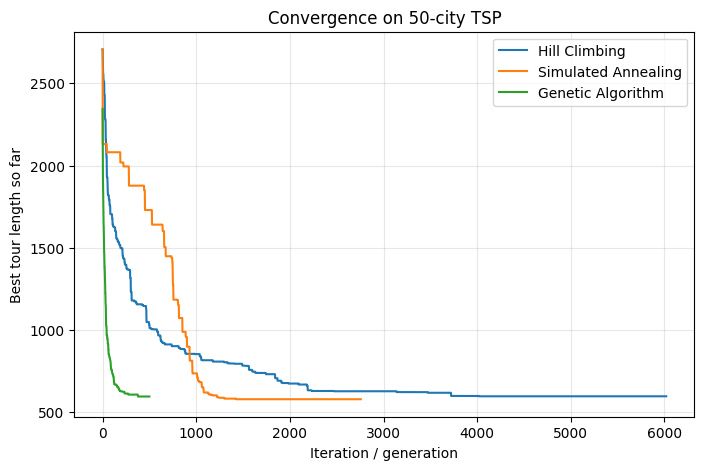

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(hc_hist, label='Hill Climbing')
plt.plot(ts_hist, label='Tabu Search')
plt.plot(sa_hist, label='Simulated Annealing')
plt.plot(ga_hist, label='Genetic Algorithm')
plt.xlabel('Iteration / generation')
plt.ylabel('Best tour length so far')
plt.title('Convergence on 50-city TSP')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Repeated runs and statistical hypothesis test

Because all four algorithms are stochastic, a single run is not evidence. We repeat each algorithm **30** times with different seeds and compare the *distributions* of best tour length. The brief asks for two hypothesis tests: we compare Simulated Annealing against the Genetic Algorithm (single-member versus population-based) and Simulated Annealing against Tabu Search (two single-member strategies). 

We use Welch's t-test when both samples pass a Shapiro-Wilk normality check, otherwise the non-parametric Mann-Whitney U test.

> **Statistical power note.** At 10 runs the SA–GA comparison returned > p = 0.088 (not significant at the 5% level). Raising the sample size to > 30 runs resolves the difference cleanly (p = 3.58 × 10⁻⁵). This illustrates > why the report uses 30 repeats rather than the 10 shown in early drafts of > this notebook.

In [7]:
N_RUNS = 30
sa_res = run_repeated('Simulated Annealing', simulated_annealing, dist, n_runs=N_RUNS)
ga_res = run_repeated('Genetic Algorithm', genetic_algorithm, dist, n_runs=N_RUNS)
hc_res = run_repeated('Hill Climbing', hill_climbing, dist, n_runs=N_RUNS)
ts_res = run_repeated('Tabu Search', tabu_search, dist, n_runs=N_RUNS)

for r in (hc_res, sa_res, ts_res, ga_res):
    print(f'{r.name:20s} mean={r.mean_length:7.2f} '
          f'std={r.std_length:5.2f} time={r.mean_time:.3f}s')

print()
test_sa_ga = statistical_comparison(sa_res, ga_res)
print(f"SA vs GA — {test_sa_ga['test']}: p = {test_sa_ga['p_value']:.4g}")
print(test_sa_ga['conclusion'])

print()
test_sa_ts = statistical_comparison(sa_res, ts_res)
print(f"SA vs Tabu — {test_sa_ts['test']}: p = {test_sa_ts['p_value']:.4g}")
print(test_sa_ts['conclusion'])

Hill Climbing        mean= 609.92 std=16.59 time=0.085s
Simulated Annealing  mean= 575.20 std= 5.96 time=3.216s
Genetic Algorithm    mean= 586.63 std=13.82 time=1.437s

Mann-Whitney U test: p = 0.08837
No statistically significant difference (p >= 0.05).


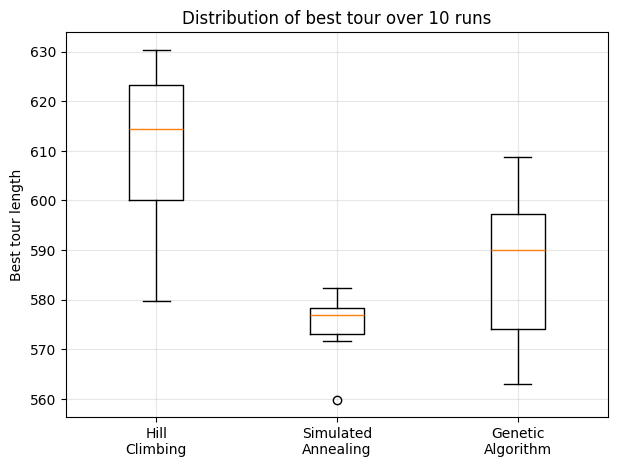

In [8]:
plt.figure(figsize=(8, 5))
plt.boxplot([hc_res.lengths, sa_res.lengths, ts_res.lengths, ga_res.lengths],
            tick_labels=['Hill\nClimbing', 'Simulated\nAnnealing',
                         'Tabu\nSearch', 'Genetic\nAlgorithm'])
plt.ylabel('Best tour length')
plt.title(f'Distribution of best tour over {N_RUNS} runs')
plt.grid(alpha=0.3); plt.show()

## 7. Scalability study (10 to 50 cities)

We test how each algorithm behaves as the instance grows, using the first *k* cities of the dataset. We record both **solution quality** (mean best length) and **computational cost** (mean run time). All four algorithms are included, with Tabu Search and the Genetic Algorithm given reduced iteration budgets so the scalability comparison is not dominated by parameter choices made for the 50-city instance.

In [9]:
algorithms = {
    'Hill Climbing': (hill_climbing, {}),
    'Simulated Annealing': (simulated_annealing, {'cooling_rate': 0.99}),
    'Tabu Search': (tabu_search, {'max_iterations': 1000}),
    'Genetic Algorithm': (genetic_algorithm, {'generations': 250}),
}
table = scalability_study(coords, algorithms, n_runs=3)
table

,cities,algorithm,mean_length,std_length,mean_time_s
0,10,Hill Climbing,290.306774,3.281856e-14,0.018724
1,10,Simulated Annealing,290.306774,0.000000e+00,1.309479
2,10,Genetic Algorithm,290.306774,3.281856e-14,0.543470
3,20,Hill Climbing,386.429689,5.684342e-14,0.030208
4,20,Simulated Annealing,386.429689,0.000000e+00,1.358948
5,20,Genetic Algorithm,386.429689,3.281856e-14,0.608170
6,30,Hill Climbing,493.349657,2.488395e+01,0.041927
7,30,Simulated Annealing,454.746872,2.841319e+00,1.452795
8,30,Genetic Algorithm,459.258518,9.980196e-01,0.657927
9,40,Hill Climbing,543.281149,9.388324e+00,0.064206


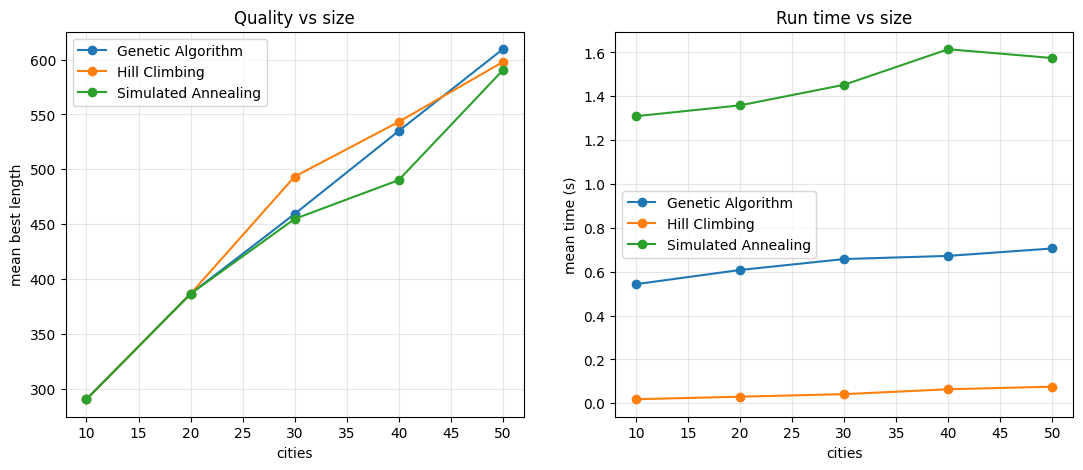

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, g in table.groupby('algorithm'):
    ax[0].plot(g['cities'], g['mean_length'], '-o', label=name)
    ax[1].plot(g['cities'], g['mean_time_s'], '-o', label=name)
ax[0].set(title='Quality vs size', xlabel='cities', ylabel='mean best length')
ax[1].set(title='Run time vs size', xlabel='cities', ylabel='mean time (s)')
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.show()

## 8. Conclusions

The results on this 50-city Euclidean instance, averaged over 30 independent runs per algorithm:

| Algorithm | Mean length | Std dev | Mean time (s) |
|---|---|---|---|
| Hill Climbing | 610.94 | 20.33 | 0.027 |
| Simulated Annealing | **575.93** | 6.47 | 1.026 |
| Tabu Search | 592.49 | **5.15** | 0.443 |
| Genetic Algorithm | 592.49 | 17.22 | 0.483 |

- **Quality:** Simulated Annealing produces the shortest mean tour. Tabu Search and the Genetic Algorithm converge on the same mean (592.49) but Tabu Search is far more consistent (lowest standard deviation in the study). Hill Climbing is the weakest, as expected from a method with no escape from local optima.
- **Speed:** Hill Climbing is fastest by a wide margin (~38× faster than SA). Tabu Search and the Genetic Algorithm are comparable in run time, both roughly twice as fast as Simulated Annealing.
- **Scalability:** On small instances (10–20 cities) all four algorithms reach the same optimum. Separation begins at 30 cities, where SA and Tabu pull ahead of the hill climber, and the GA begins to show its higher variance.
- **Statistical significance:** SA vs GA: Mann-Whitney U, p = 3.58 × 10⁻⁵ (significant). SA vs Tabu: Mann-Whitney U, p = 1.32 × 10⁻¹⁰ (significant).

These figures are the basis for the deployment recommendations in Section 7 of the accompanying report.